In [1]:
# Lets do the necessary imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/ingledarshan/upGrad_Darshan/refs/heads/main/vgsales.csv')
df.head()   

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
# Dataset: Video Game Sales

# Rank – The ranking of the video game based on its total global sales, where a lower number indicates higher sales.

# Name – The official title of the video game.

# Platform – The gaming platform or console on which the game was released (for example, PS4, Xbox, Wii, PC).

# Year – The year in which the video game was originally released.

# Genre – The category or type of the video game based on gameplay style, such as Action, Sports, or Role-Playing.

# Publisher – The company responsible for publishing and distributing the video game.

# NA_Sales – Total sales of the video game in North America, measured in millions of units.

# EU_Sales – Total sales of the video game in Europe, measured in millions of units.

# JP_Sales – Total sales of the video game in Japan, measured in millions of units.

# Other_Sales – Total sales of the video game in regions outside North America, Europe, and Japan, measured in millions of units.

# Global_Sales – The total worldwide sales of the video game, calculated as the sum of sales from all regions, measured in millions of units.

In [4]:
# Global_Sales represents the total worldwide demand for a video game and is the most business-critical outcome variable. All other columns (platform, genre, region-wise sales, publisher, year, etc.) are either drivers, contributors, or contextual features that influence or explain this final outcome.

# Target Variable: Global_Sales

In [5]:
# Business Context

# A global video game publishing company wants to predict the worldwide commercial success of a video game before or shortly after its release. Developing and marketing a game involves high costs across development, licensing, marketing, and distribution. Poor sales forecasts can lead to overproduction, inefficient marketing spend, and revenue loss.

# The company has access to historical data containing information about previously released video games, including their platform, genre, publisher, release year, and regional sales performance.

# Problem Statement

# Using historical video game sales data, build a machine learning model that can accurately predict the Global Sales (in millions of units) of a video game based on its characteristics such as platform, genre, publisher, release year, and regional market performance.

# Objective
# - To learn patterns from past video game releases
# - To estimate expected global sales volume for a new or upcoming game
# - To support data-driven decision making in:
#     - Marketing budget allocation
#     - Platform prioritization
#     - Genre investment strategy
#     - Regional launch planning

In [6]:
# Input Features (Independent Variables)
# - Platform – Helps capture hardware popularity and market reach
# - Year – Captures market trends, console generations, and gaming industry growth
# - Genre – Reflects customer preferences and demand patterns
# - Publisher – Represents brand strength, distribution power, and marketing capability
# - NA_Sales, EU_Sales, JP_Sales, Other_Sales – Indicates regional performance patterns that influence global outcomes

# Output Variable (Target)
# Global_Sales – Total worldwide sales of the video game in millions

In [7]:
# ML Value to the Business:
# - Predict high-performing game concepts early
# - Reduce financial risk by identifying low-potential projects
# - Optimize regional marketing strategies
# - Support executives with quantitative forecasts instead of intuition

In [8]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [9]:
# How many rows (video games) and columns (features) are present in the dataset?
df.shape

(16598, 11)

In [10]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [11]:
# What is the data type of each column (numeric, categorical, integer, float)?
df.dtypes

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [12]:
# Year column is of object type, we need to convert it to integer type
# df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
# or
df['Year'] = df['Year'].astype('Int64')

# Lets check the data types again
df.dtypes

Rank              int64
Name             object
Platform         object
Year              Int64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [13]:
# Which columns are categorical and which are numerical?
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
numerical_columns = df.select_dtypes(include=['number']).columns

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)

Categorical columns: Index(['Name', 'Platform', 'Genre', 'Publisher'], dtype='object')
Numerical columns: Index(['Rank', 'Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
       'Global_Sales'],
      dtype='object')


In [14]:
# Are there any columns that look like identifiers rather than useful predictors (for example, Rank or Name)?
df.select_dtypes(include=['object', 'category']).columns

Index(['Name', 'Platform', 'Genre', 'Publisher'], dtype='object')

In [15]:
# Identifier-like column: Name
# Usable categorical predictors: Platform, Genre, Publisher
# Since 'Name' is an identifier-like column, we will drop it from the dataset
df = df.drop(columns=['Name'])
df.head()

,Rank,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [16]:
# Are there missing values in any columns?
df.isnull().sum().sort_values(ascending=False)

Year            271
Publisher        58
Platform          0
Rank              0
Genre             0
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [17]:
df["Year"].skew()

# Skewness Range:
# If this value is between:
# -0.5 and 0.5, the distribution of the value is almost symmetrical
# -1 and -0.5, the data is negatively skewed, and if it is between 0.5 to 1, the data is positively skewed. The skewness is moderate.
# If the skewness is lower than -1 (negatively skewed) or greater than 1 (positively skewed), the data is highly skewed.


np.float64(-1.002560494621347)

In [18]:
# Year (271 missing)
# Nature of column:
# Temporal feature i.e., it represents the year of release of the video game
# Important for trend analysis and ML
# Missing because of incomplete metadata, not because sales are missing

# Best Strategy for THIS dataset
# Option A (Recommended for ML): Impute using median year

df["Year"].fillna(df["Year"].median(), inplace=True)

# Lets check again for missing values
df.isnull().sum().sort_values(ascending=False)

Publisher       58
Rank             0
Platform         0
Year             0
Genre            0
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

In [19]:
df.head()

,Rank,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [20]:
df["Publisher"].nunique()

578

In [21]:
df["Publisher"].value_counts()

Publisher
Electronic Arts                 1351
Activision                       975
Namco Bandai Games               932
Ubisoft                          921
Konami Digital Entertainment     832
                                ... 
Revolution (Japan)                 1
Saurus                             1
Palcom                             1
Rain Games                         1
UIG Entertainment                  1
Name: count, Length: 578, dtype: int64

In [22]:
# Publisher (58 missing)
# Nature of column
# Categorical
# High-cardinality i.e., many unique values (publishers)
# Missing values are very few

# Best Strategy (Industry-standard)
# Create an explicit category: 'Unknown'

# Why this is better than dropping:
# - Retains data
# - Keeps signal that publisher info was unavailable
# - Helps tree-based models and encoding

# This is far superior to mode imputation for categorical columns.

df["Publisher"].fillna('Unknown', inplace=True)

# Lets check again for missing values
df.isnull().sum().sort_values(ascending=False)

Rank            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [23]:
# Are there any duplicate records in the dataset?
df.duplicated().sum()

np.int64(0)

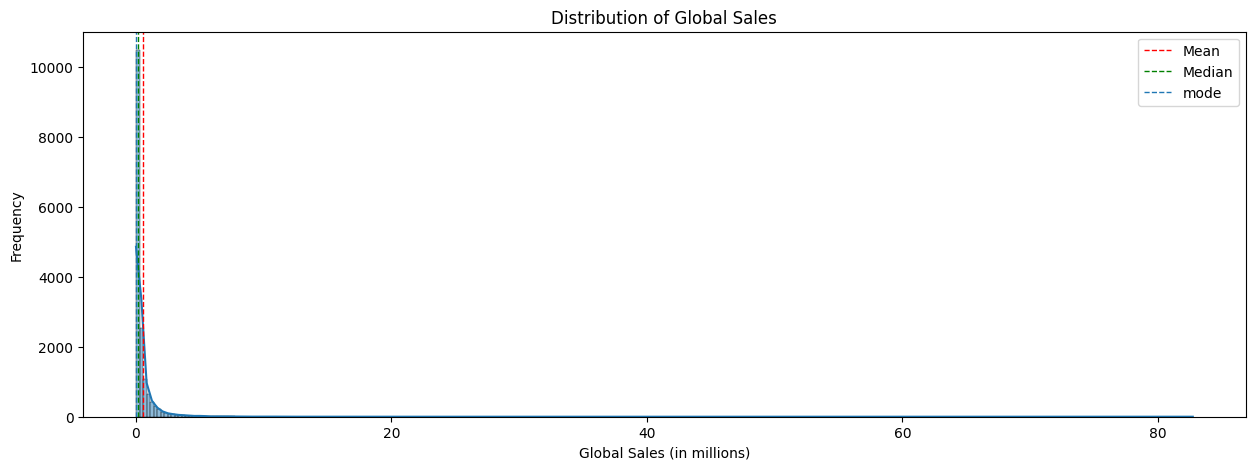

In [24]:
plt.figure(figsize=(15,5))
sns.histplot((df['Global_Sales']), bins=300, kde=True)
plt.title('Distribution of Global Sales')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Frequency')
plt.axvline(df['Global_Sales'].mean(), color='r', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(df['Global_Sales'].median(), color='g', linestyle='dashed', linewidth=1, label='Median')
plt.axvline(df['Global_Sales'].mode()[0],linestyle='dashed', linewidth=1,label='mode')
plt.legend()
plt.show()

In [25]:
df.Global_Sales

0        82.74
1        40.24
2        35.82
3        33.00
4        31.37
         ...  
16593     0.01
16594     0.01
16595     0.01
16596     0.01
16597     0.01
Name: Global_Sales, Length: 16598, dtype: float64

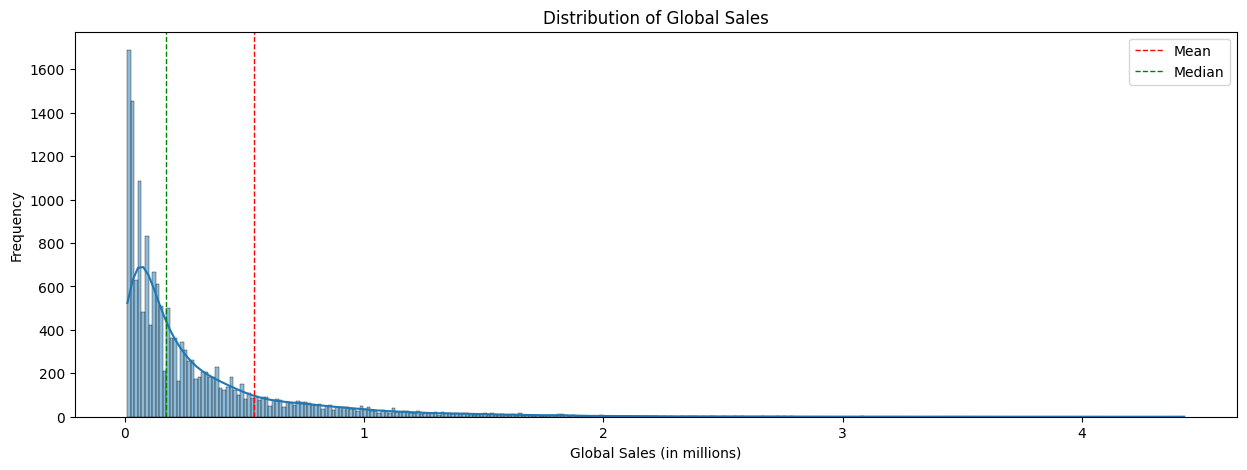

In [26]:
# What is the distribution of Global_Sales?
plt.figure(figsize=(15,5))
sns.histplot(np.log1p(df['Global_Sales']), bins=300, kde=True)
plt.title('Distribution of Global Sales')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Frequency')
plt.axvline(df['Global_Sales'].mean(), color='r', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(df['Global_Sales'].median(), color='g', linestyle='dashed', linewidth=1, label='Median')
plt.legend()
plt.show()

In [27]:
# Is Global_Sales right-skewed or normally distributed?
# Global_Sales is right-skewed as the mean is greater than the median and the distribution has a long tail on the right side.
# This indicates that while most games have lower sales, a few blockbuster titles achieve very high sales, pulling the average up.

In [28]:
# What are the minimum, maximum, mean, and median Global_Sales values?
min_sales = df['Global_Sales'].min()
max_sales = df['Global_Sales'].max()
mean_sales = df['Global_Sales'].mean()
median_sales = df['Global_Sales'].median()

min_sales, max_sales, mean_sales, median_sales

(np.float64(0.01),
 np.float64(82.74),
 np.float64(0.5374406555006629),
 np.float64(0.17))

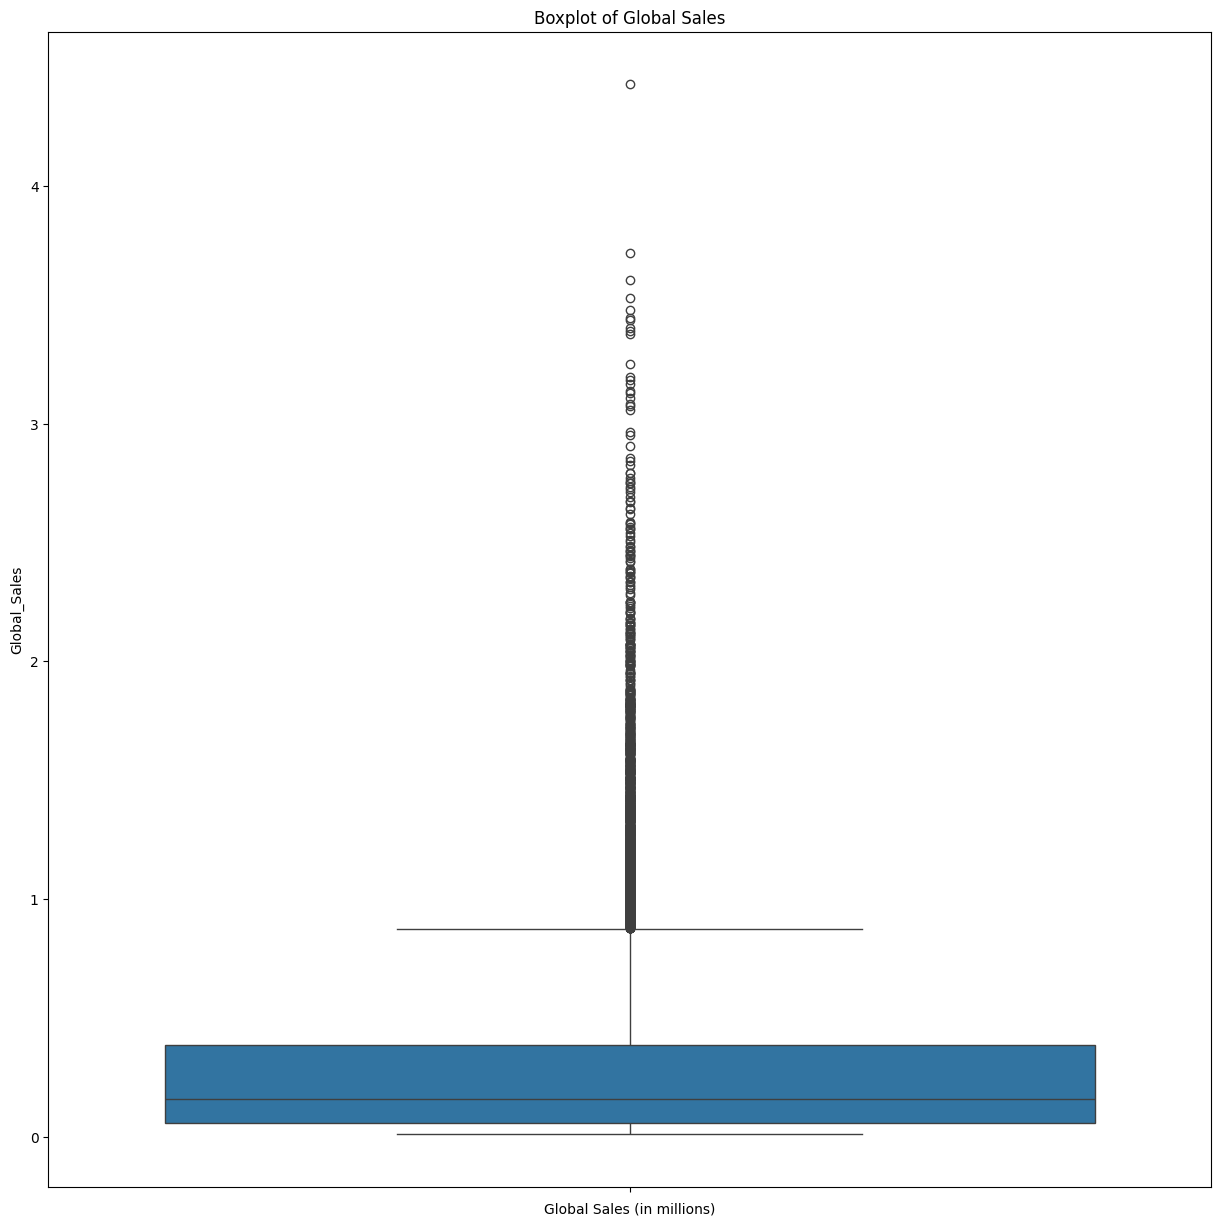

In [29]:
# Are there extreme outliers in Global_Sales?
plt.figure(figsize=(15, 15))
sns.boxplot(y=np.log1p(df['Global_Sales']))
plt.title('Boxplot of Global Sales')
plt.xlabel('Global Sales (in millions)')
plt.show()

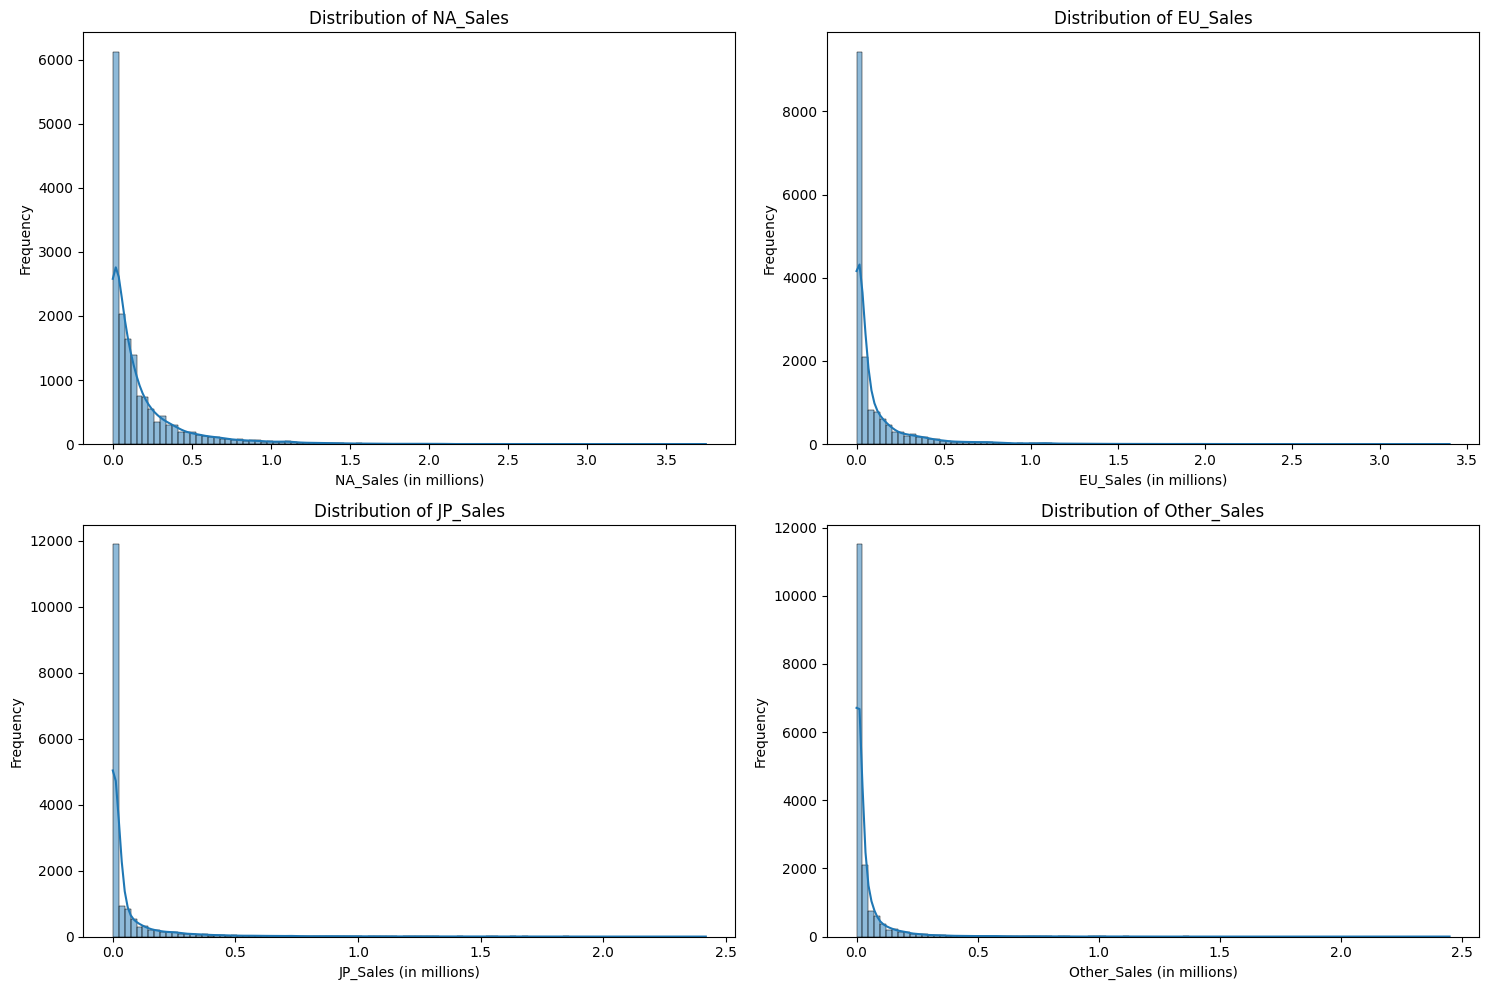

In [30]:
# How do regional sales (NA, EU, JP, Other) individually behave?
plt.figure(figsize=(15, 10))
regions = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
for i, region in enumerate(regions,1):
    plt.subplot(2, 2, i)
    sns.histplot(np.log1p(df[region]), bins=100, kde=True)
    plt.title(f'Distribution of {region}')
    plt.xlabel(f'{region} (in millions)')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [31]:
# Which region contributes the most to overall sales on average?
average_sales_by_region = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].mean()
average_sales_by_region

NA_Sales       0.264667
EU_Sales       0.146652
JP_Sales       0.077782
Other_Sales    0.048063
dtype: float64

In [32]:
df.head()

,Rank,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [33]:
# How many unique platforms are present in the dataset?
unique_platforms = df['Platform'].nunique()
unique_platforms

31

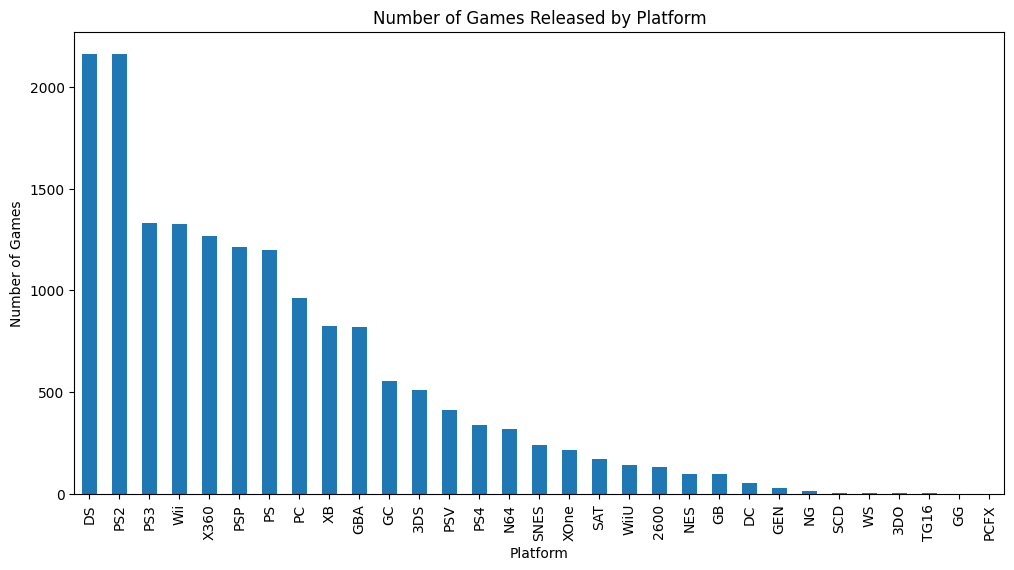

In [34]:
# Which platforms have released the highest number of games?
platform_game_counts = df['Platform'].value_counts()
platform_game_counts.plot(kind='bar', figsize=(12,6))
plt.title('Number of Games Released by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Games')
plt.show()

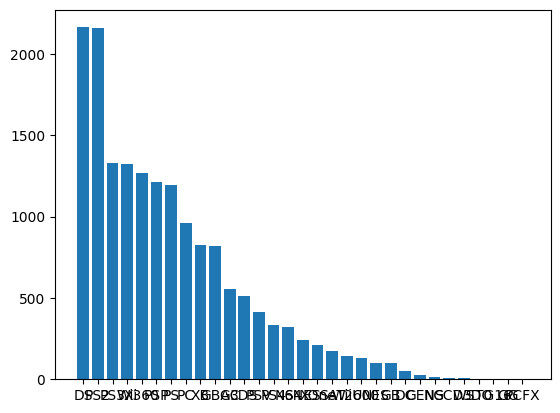

In [35]:
a= df['Platform'].value_counts().reset_index(name='count')
plt.bar(x=a['Platform'],height=a['count'])
plt.show()


In [36]:
df.head()

,Rank,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [37]:
# How many unique genres exist?
unique_genres = df['Genre'].nunique()
unique_genres

12

In [38]:
df['Genre'].value_counts()

Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64

In [39]:
# Which genre appears most frequently?
most_frequent_genre = df['Genre'].value_counts().idxmax()
most_frequent_genre

'Action'

In [40]:
df.head()

,Rank,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [41]:
# How many unique publishers are present?
unique_publishers = df['Publisher'].nunique()
unique_publishers

578

In [42]:
# Are there a few dominant publishers controlling most game releases?
dominant_publishers = df['Publisher'].value_counts().head()
dominant_publishers

Publisher
Electronic Arts                 1351
Activision                       975
Namco Bandai Games               932
Ubisoft                          921
Konami Digital Entertainment     832
Name: count, dtype: int64

In [43]:
df.head()

,Rank,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [44]:
df['Year'].value_counts().head()

Year
2007    1473
2009    1431
2008    1428
2010    1259
2011    1139
Name: count, dtype: Int64

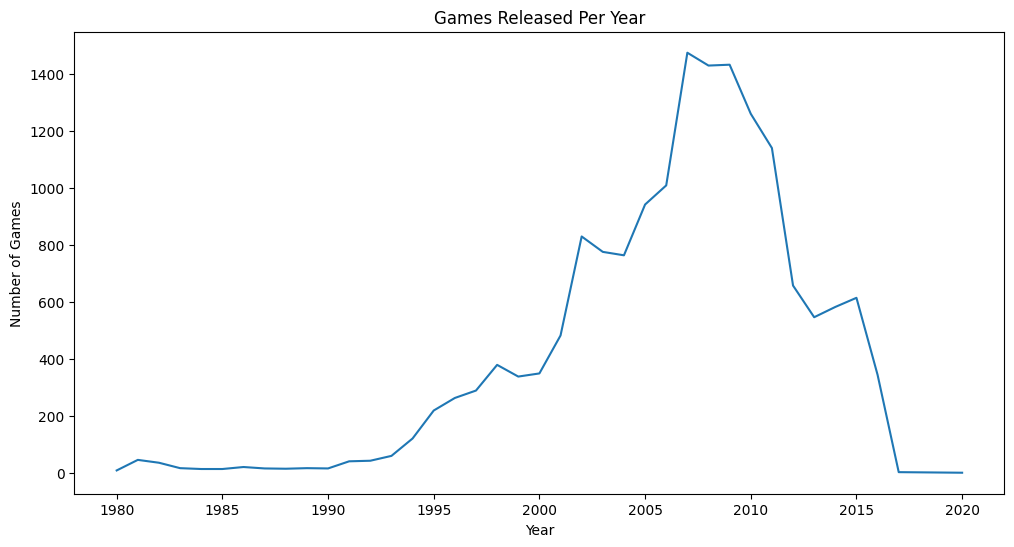

In [45]:
import matplotlib.pyplot as plt

games_released_per_year = df['Year'].value_counts().sort_index().reset_index(name='count')

plt.figure(figsize=(12,6))
plt.plot(games_released_per_year['Year'],games_released_per_year['count'])
plt.xlabel("Year")
plt.ylabel("Number of Games")
plt.title("Games Released Per Year")
plt.show()

In [46]:
games_released_per_year.head()

,Year,count
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14


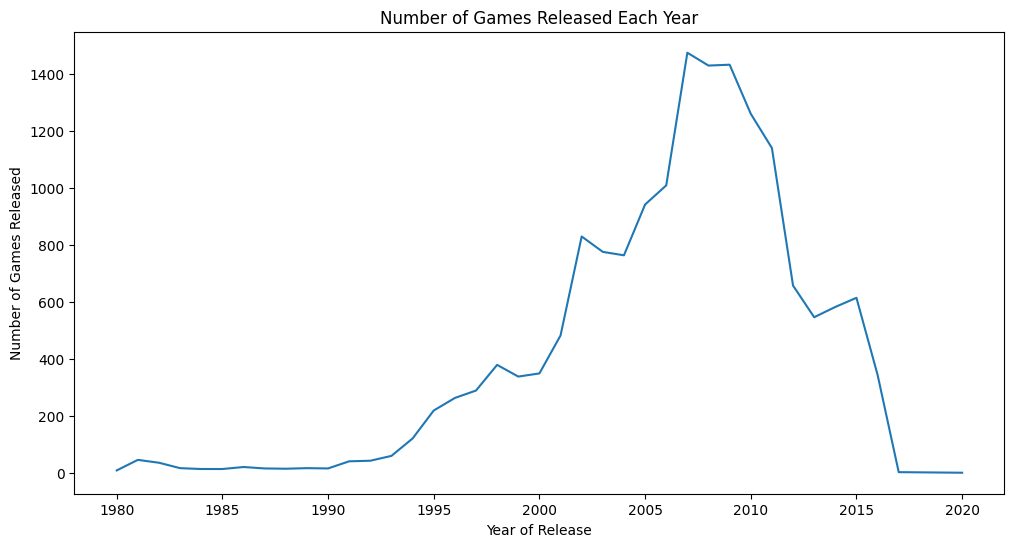

In [47]:
# How many games were released each year?
games_released_per_year = df['Year'].value_counts().sort_index()
games_released_per_year.plot(kind='line', figsize=(12,6))
plt.title('Number of Games Released Each Year')
plt.xlabel('Year of Release')
plt.ylabel('Number of Games Released')
plt.show()

In [48]:
df.head()

,Rank,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [49]:
# Which years show peak activity in the gaming industry?
peak_years = games_released_per_year[games_released_per_year == games_released_per_year.max()]
peak_years

Year
2007    1473
Name: count, dtype: Int64

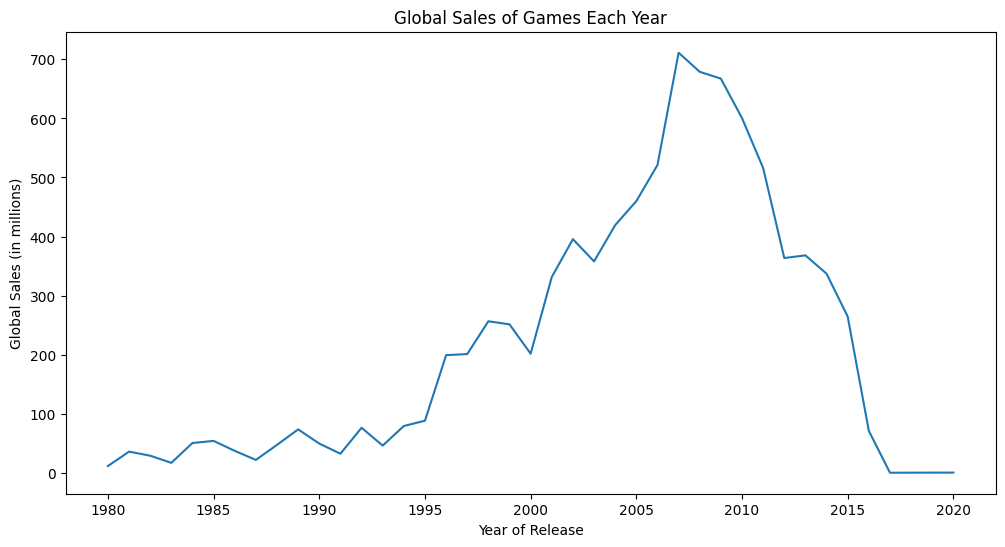

In [50]:
# How have Global_Sales evolved across different years?
global_sales_per_year = df.groupby('Year')['Global_Sales'].sum().sort_index()
global_sales_per_year.plot(kind='line', figsize=(12,6))
plt.title('Global Sales of Games Each Year')
plt.xlabel('Year of Release')
plt.ylabel('Global Sales (in millions)')
plt.show()

In [51]:
global_sales_per_year.reset_index(name='sales').head()

,Year,sales
0,1980,11.38
1,1981,35.77
2,1982,28.86
3,1983,16.79
4,1984,50.36


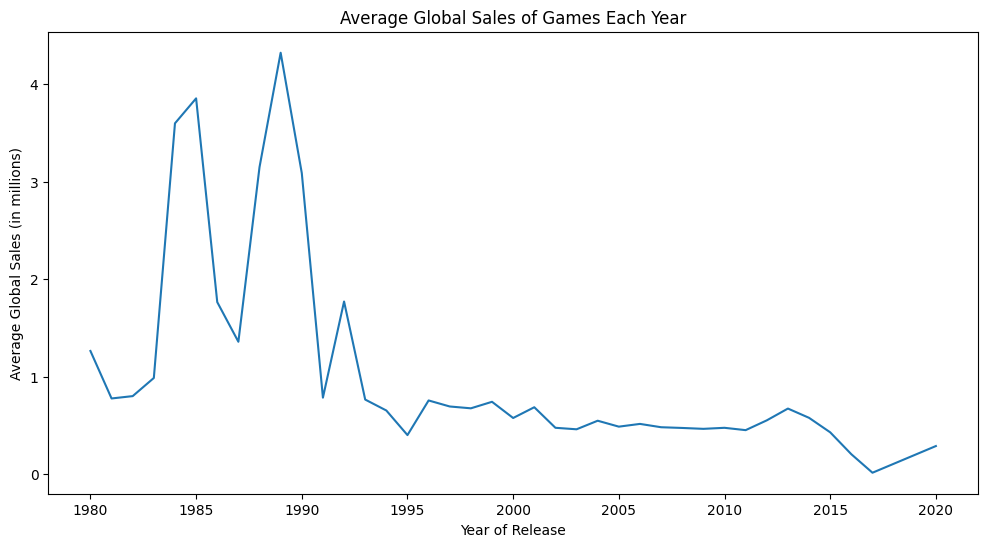

In [52]:
# Are newer games selling more or less compared to older games?
average_sales_per_year = df.groupby('Year')['Global_Sales'].mean().sort_index()
average_sales_per_year.plot(kind='line', figsize=(12,6))
plt.title('Average Global Sales of Games Each Year')
plt.xlabel('Year of Release')
plt.ylabel('Average Global Sales (in millions)')
plt.show()

**Is there a clear rise and fall pattern linked to console generations?**

* Average global sales per game increase sharply during the mid-1980s to early-1990s.
* This peak aligns with early successful console generations (NES, SNES, Sega Genesis).
* Fewer games and a rapidly growing user base led to higher per-game sales.
* After the early-1990s peak, average sales decline as the market becomes saturated.
* In later years, many more games are released, spreading sales across titles.
* Small bumps appear around new console launches, but not at earlier peak levels.
* Recent years show lower averages due to digital distribution and fragmented platforms.

**Conclusion:**
Yes, the dataset shows a clear rise-and-fall pattern tied to console generations, where early-generation games sell more on average than late-generation releases.


In [53]:
df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head()

Platform
PS2     1255.64
X360     979.96
PS3      957.84
Wii      926.71
DS       822.49
Name: Global_Sales, dtype: float64

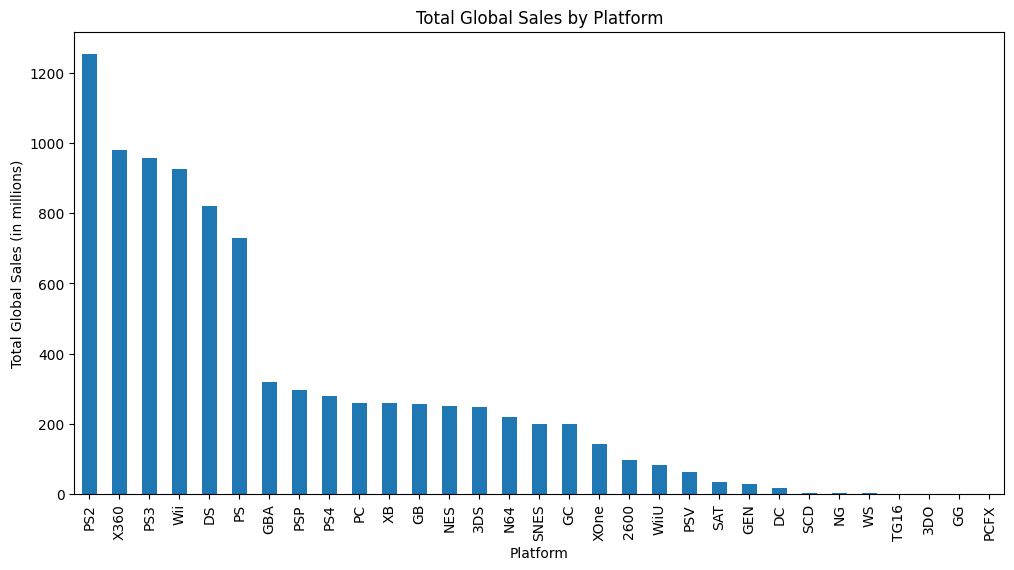

In [54]:
# Which platforms generate the highest total Global_Sales?
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)
platform_sales.plot(kind='bar', figsize=(12,6))
plt.title('Total Global Sales by Platform')
plt.xlabel('Platform')
plt.ylabel('Total Global Sales (in millions)')
plt.show()

In [55]:
df.groupby('Platform')['Global_Sales'].mean().sort_values(ascending=False)

Platform
GB      2.606633
NES     2.561939
GEN     1.050370
SNES    0.837029
PS4     0.827679
X360    0.774672
2600    0.729925
PS3     0.720722
Wii     0.699404
N64     0.686144
XOne    0.662254
PS      0.610920
PS2     0.581046
WiiU    0.572448
3DS     0.486169
GBA     0.387470
DS      0.380254
GC      0.358561
XB      0.313422
SCD     0.311667
DC      0.307115
PC      0.269604
PSP     0.244254
WS      0.236667
SAT     0.194162
PSV     0.149952
NG      0.120000
TG16    0.080000
GG      0.040000
3DO     0.033333
PCFX    0.030000
Name: Global_Sales, dtype: float64

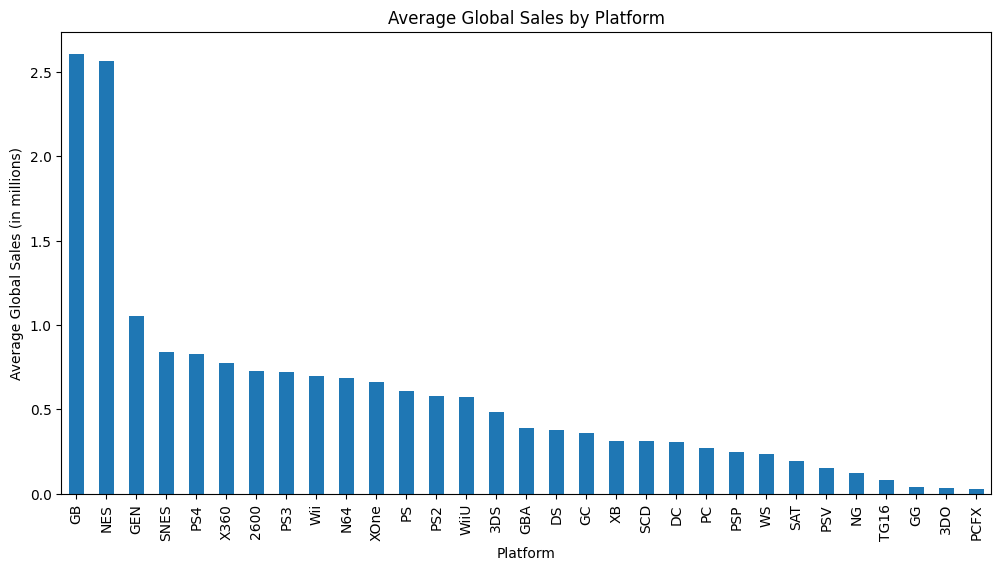

In [56]:
# Which platforms have the highest average Global_Sales per game?
average_platform_sales = df.groupby('Platform')['Global_Sales'].mean().sort_values(ascending=False)
average_platform_sales.plot(kind='bar', figsize=(12,6))
plt.title('Average Global Sales by Platform')
plt.xlabel('Platform')
plt.ylabel('Average Global Sales (in millions)')
plt.show()

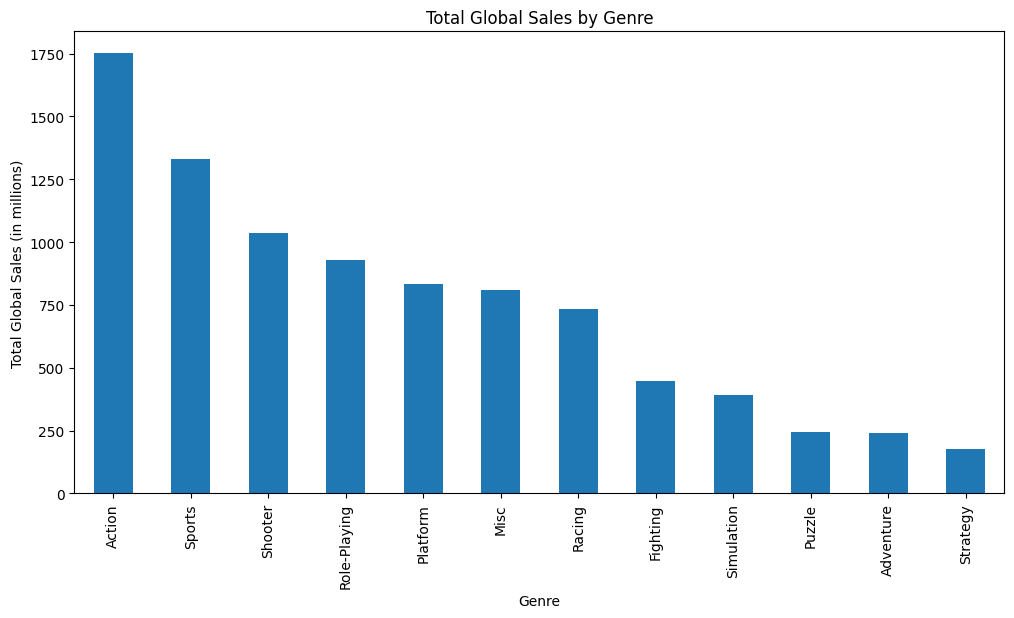

In [57]:
# Which genres generate the highest Global_Sales?
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
genre_sales.plot(kind='bar', figsize=(12,6))
plt.title('Total Global Sales by Genre')
plt.xlabel('Genre')
plt.ylabel('Total Global Sales (in millions)')
plt.show()

In [58]:
df.head()

,Rank,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [59]:
a=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
x1=df.groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
x1



,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,877.83,525.00,159.95,187.38
Adventure,105.80,64.13,52.07,16.81
Fighting,223.59,101.32,87.35,36.68
Misc,410.24,215.98,107.76,75.32
Platform,447.05,201.63,130.77,51.59
Puzzle,123.78,50.78,57.31,12.55
Racing,359.42,238.39,56.69,77.27
Role-Playing,327.28,188.06,352.31,59.61
Shooter,582.60,313.27,38.28,102.69


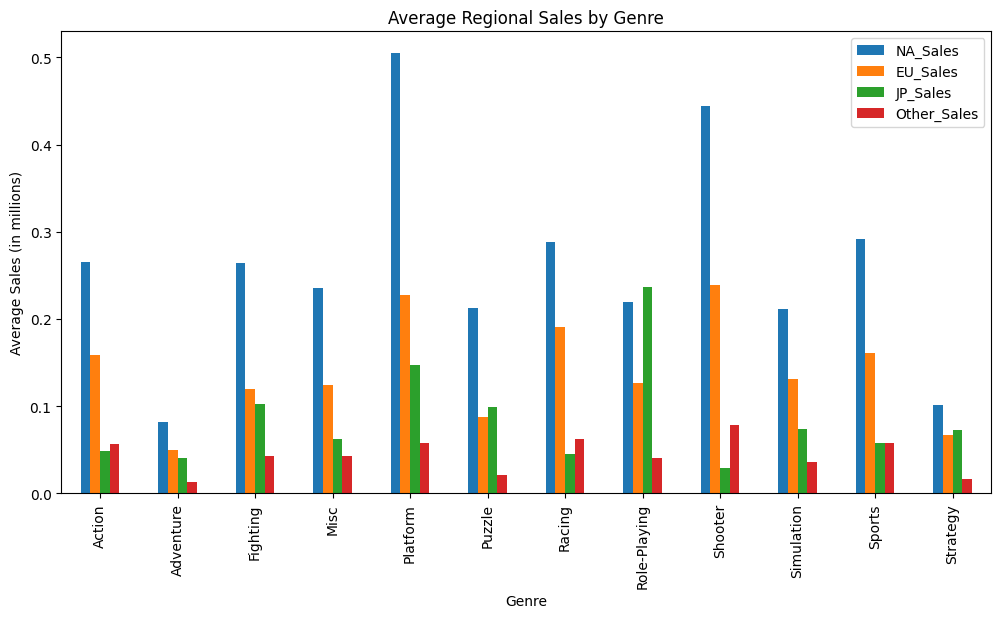

In [60]:
# Do some genres perform consistently well across all regions?
genre_region_sales = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].mean()
genre_region_sales.plot(kind='bar', figsize=(12,6))
plt.title('Average Regional Sales by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Sales (in millions)')
plt.show()

In [61]:
genre_region_sales

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,0.264726,0.158323,0.048236,0.056508
Adventure,0.082271,0.049868,0.040490,0.013072
Fighting,0.263667,0.119481,0.103007,0.043255
Misc,0.235906,0.124198,0.061967,0.043312
Platform,0.504571,0.227573,0.147596,0.058228
Puzzle,0.212680,0.087251,0.098471,0.021564
Racing,0.287766,0.190865,0.045388,0.061865
Role-Playing,0.219946,0.126384,0.236767,0.040060
Shooter,0.444733,0.239137,0.029221,0.078389


**Insights from Average Regional Sales by Genre**

* Platform and Shooter genres show the highest average sales in North America and Europe, indicating strong Western market dominance.
* Role-Playing games perform exceptionally well in Japan compared to other genres, highlighting strong regional preference.
* Sports games have consistently strong sales across North America and Europe, but weaker performance in Japan.
* Action games perform well across all regions, showing balanced global appeal.
* Adventure and Strategy genres have relatively low average sales across all regions, indicating niche demand.
* Other regions contribute the smallest share of sales across all genres but follow similar preference patterns as North America and Europe.

**Conclusion:**
Genre performance varies significantly by region, with only a few genres (Action, Platform) showing relatively consistent global appeal, while others are highly region-specific.


In [62]:
df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)

Publisher
Nintendo                        1786.56
Electronic Arts                 1110.32
Activision                       727.46
Sony Computer Entertainment      607.50
Ubisoft                          474.72
Take-Two Interactive             399.54
THQ                              340.77
Konami Digital Entertainment     283.64
Sega                             272.99
Namco Bandai Games               254.09
Name: Global_Sales, dtype: float64

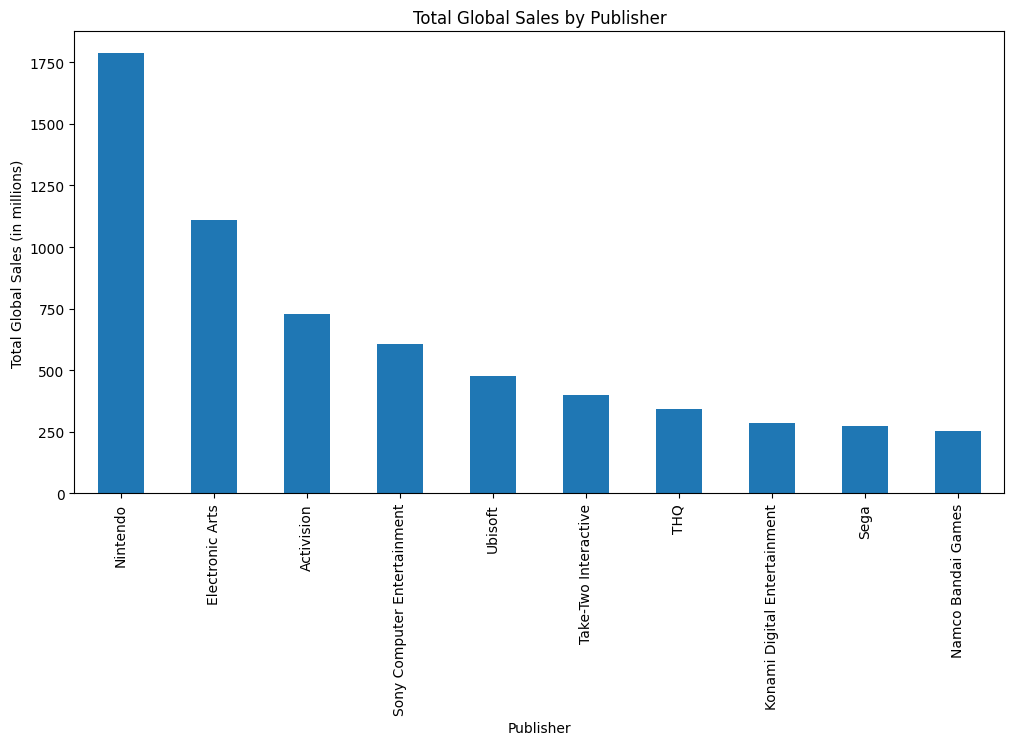

In [63]:
# Which publishers generate the highest Global_Sales?
publisher_sales = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
publisher_sales.plot(kind='bar', figsize=(12,6))
plt.title('Total Global Sales by Publisher')
plt.xlabel('Publisher')
plt.ylabel('Total Global Sales (in millions)')
plt.show()

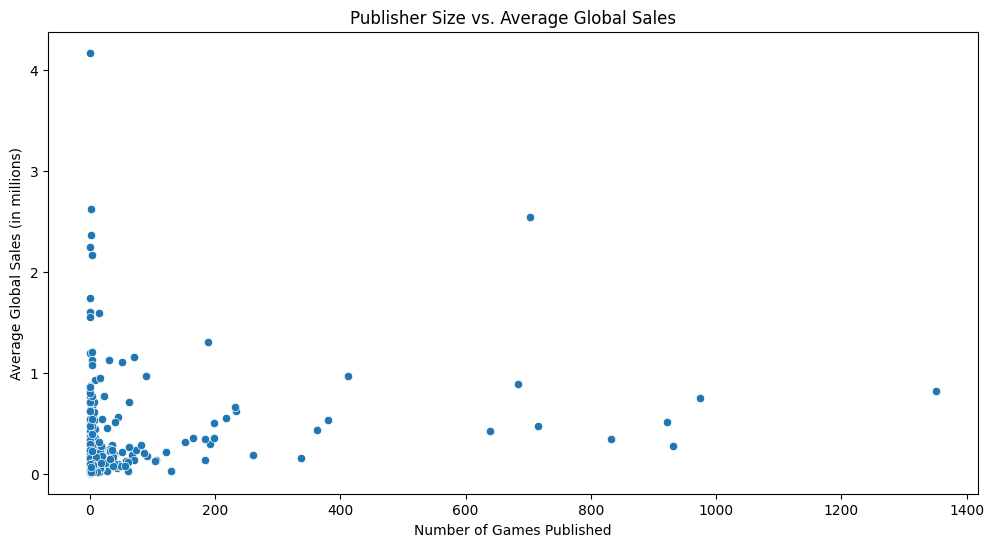

In [64]:
# Is publisher size correlated with higher sales?
publisher_game_counts = df['Publisher'].value_counts()
publisher_avg_sales = df.groupby('Publisher')['Global_Sales'].mean()
publisher_size_sales = pd.DataFrame({
    'Game_Count': publisher_game_counts,
    'Avg_Global_Sales': publisher_avg_sales
}).dropna()
plt.figure(figsize=(12,6))
sns.scatterplot(data=publisher_size_sales, x='Game_Count', y='Avg_Global_Sales')
plt.title('Publisher Size vs. Average Global Sales')
plt.xlabel('Number of Games Published')
plt.ylabel('Average Global Sales (in millions)')
plt.show()

**Insights from Publisher Size vs. Average Global Sales**

* There is no strong linear relationship between the number of games published and average global sales.
* Several small publishers achieve very high average sales, indicating hit-driven success.
* Large publishers release many games but tend to have lower average sales per title.
* High-volume publishing appears to dilute average performance due to many low-selling titles.
* A few mid-sized publishers show balanced performance with reasonable volume and sales.
* Outliers exist where publishers with few games have exceptionally high averages.

**Conclusion:**
Publisher size alone does not guarantee higher average sales; success in this dataset is driven more by blockbuster titles than by the sheer number of games released.


In [65]:
publisher_size_sales

,Game_Count,Avg_Global_Sales
Publisher,,
10TACLE Studios,3,0.036667
1C Company,3,0.033333
20th Century Fox Video Games,5,0.388000
2D Boy,1,0.040000
3DO,36,0.281111
...,...,...
id Software,1,0.030000
imageepoch Inc.,2,0.020000
inXile Entertainment,1,0.100000


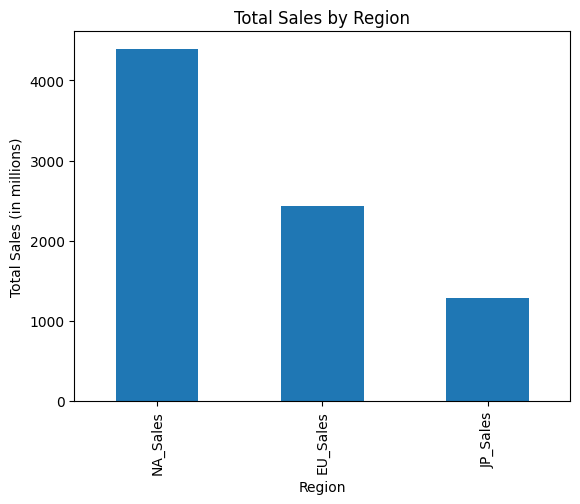

In [66]:
# How do sales patterns differ across North America, Europe, and Japan?
region_sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()
region_sales.plot(kind='bar')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales (in millions)')
plt.show()

In [67]:
# np.arange(len(japan_popular_genres.index))

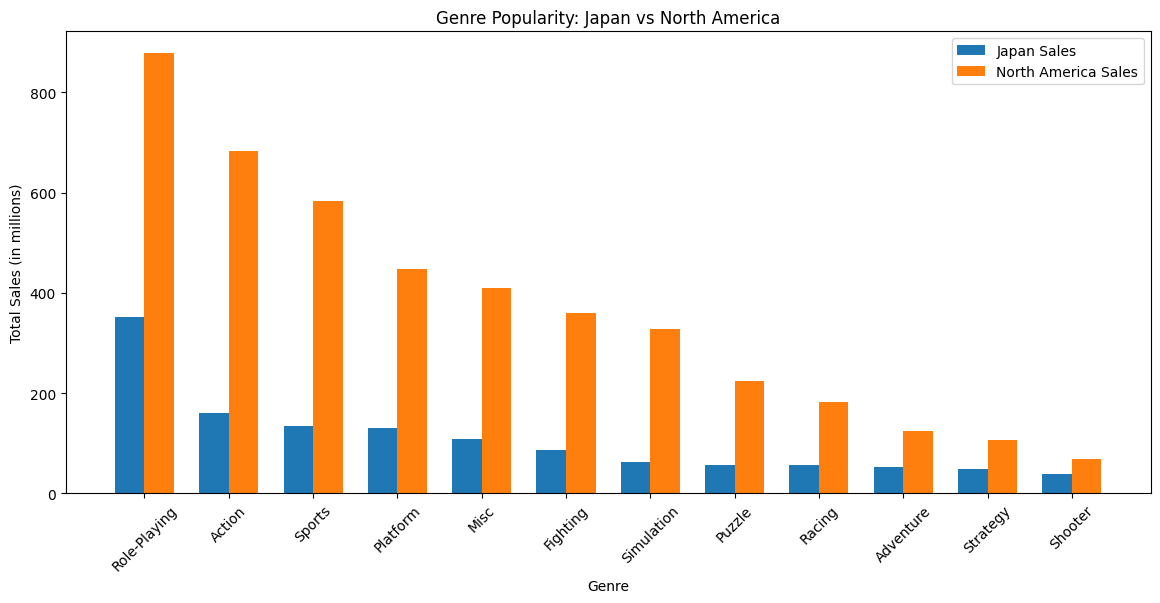

In [68]:
# Which genres are more popular in Japan compared to North America?
japan_popular_genres = df.groupby('Genre')['JP_Sales'].sum().sort_values(ascending=False)
na_popular_genres = df.groupby('Genre')['NA_Sales'].sum().sort_values(ascending=False)
# Plotting the comparison
plt.figure(figsize=(14,6))
width = 0.35  # the width of the bars
x = np.arange(len(japan_popular_genres.index))
plt.bar(x - width/2, japan_popular_genres.values, width, label='Japan Sales')
plt.bar(x + width/2, na_popular_genres.values, width, label='North America Sales')
plt.xticks(x, japan_popular_genres.index, rotation=45)
plt.title('Genre Popularity: Japan vs North America')
plt.xlabel('Genre')
plt.ylabel('Total Sales (in millions)')
plt.legend()
plt.show()

In [69]:
# Which platforms perform well globally but poorly in Japan?
platform_global_sales = df.groupby('Platform')['Global_Sales'].sum()
platform_japan_sales = df.groupby('Platform')['JP_Sales'].sum()
platform_performance = pd.DataFrame({
    'Global_Sales': platform_global_sales,
    'JP_Sales': platform_japan_sales
})
platform_performance['JP_to_Global_Ratio'] = platform_performance['JP_Sales'] / platform_performance['Global_Sales']
platform_performance = platform_performance.sort_values(by='JP_to_Global_Ratio')
platform_performance

,Global_Sales,JP_Sales,JP_to_Global_Ratio
Platform,,,
2600,97.08,0.00,0.000000
PC,258.82,0.17,0.000657
XOne,141.06,0.34,0.002410
XB,258.26,1.38,0.005343
X360,979.96,12.43,0.012684
PS4,278.10,14.30,0.051420
Wii,926.71,69.35,0.074835
PS3,957.84,79.99,0.083511
GEN,28.36,2.67,0.094147


In [70]:
# Are there region-specific platforms or genres?
# Identifying platforms with high sales in Japan but low globally
japan_focused_platforms = platform_performance[platform_performance['JP_to_Global_Ratio'] > 0.5]
japan_focused_platforms
# Now we have identified platforms that perform significantly better in Japan compared to their global performance.

,Global_Sales,JP_Sales,JP_to_Global_Ratio
Platform,,,
DC,15.97,8.56,0.536005
SNES,200.05,116.55,0.582604
SAT,33.59,32.26,0.960405
NG,1.44,1.44,1.000000
GG,0.04,0.04,1.000000
3DO,0.10,0.10,1.000000
PCFX,0.03,0.03,1.000000
WS,1.42,1.42,1.000000
TG16,0.16,0.16,1.000000


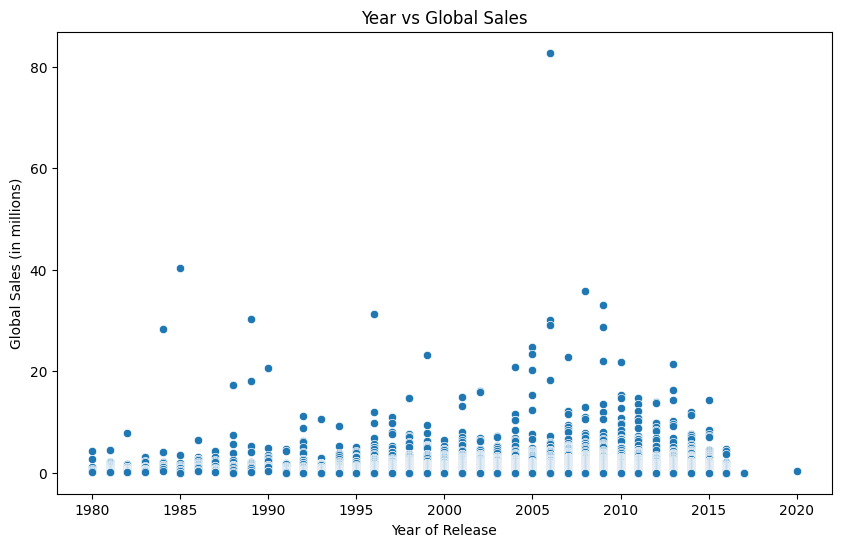

In [71]:
# Does Year have a correlation with Global_Sales?
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x='Year', y='Global_Sales')
plt.title('Year vs Global Sales')
plt.xlabel('Year of Release')
plt.ylabel('Global Sales (in millions)')
plt.show()

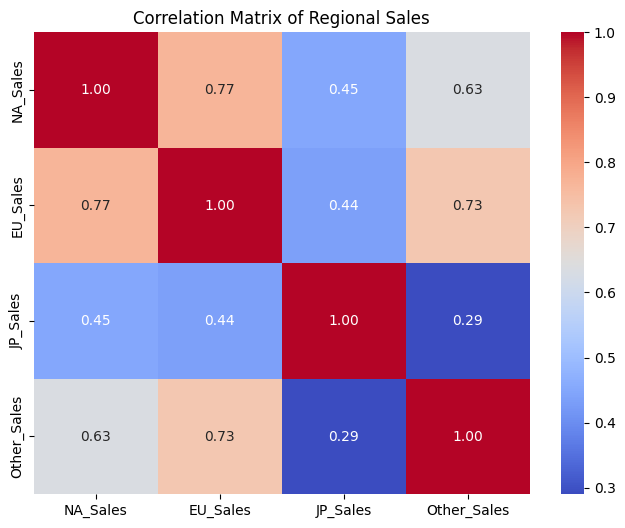

In [72]:
# Are there multicollinearity concerns among regional sales features?
regional_sales_corr = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(regional_sales_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Regional Sales')
plt.show()

In [73]:
# Which games are extreme outliers in terms of Global_Sales?
threshold = df['Global_Sales'].quantile(0.99)  # Top 1% as outliers
outlier_games = df[df['Global_Sales'] > threshold]
outlier_games[['Platform', 'Genre', 'Publisher', 'Year', 'Global_Sales']]
# These games have exceptionally high global sales compared to the rest of the dataset.

,Platform,Genre,Publisher,Year,Global_Sales
0,Wii,Sports,Nintendo,2006,82.74
1,NES,Platform,Nintendo,1985,40.24
2,Wii,Racing,Nintendo,2008,35.82
3,Wii,Sports,Nintendo,2009,33.00
4,GB,Role-Playing,Nintendo,1996,31.37
...,...,...,...,...,...
161,PSP,Role-Playing,Capcom,2008,5.50
162,GBA,Platform,Nintendo,2001,5.49
163,GBA,Racing,Nintendo,2001,5.47
164,GBA,Platform,Nintendo,2001,5.46


In [74]:
# Are a small number of games responsible for a large portion of total revenue?
total_global_sales = df['Global_Sales'].sum()
top_1_percent_sales = outlier_games['Global_Sales'].sum()
percentage_contribution = (top_1_percent_sales / total_global_sales) * 100
percentage_contribution

np.float64(21.083937563617937)

In [75]:
# percentage_contribution = 21.083937563617937 means that the top 1% of games (in terms of Global_Sales) are responsible for generating approximately 21.08% of the total global sales revenue in the dataset.

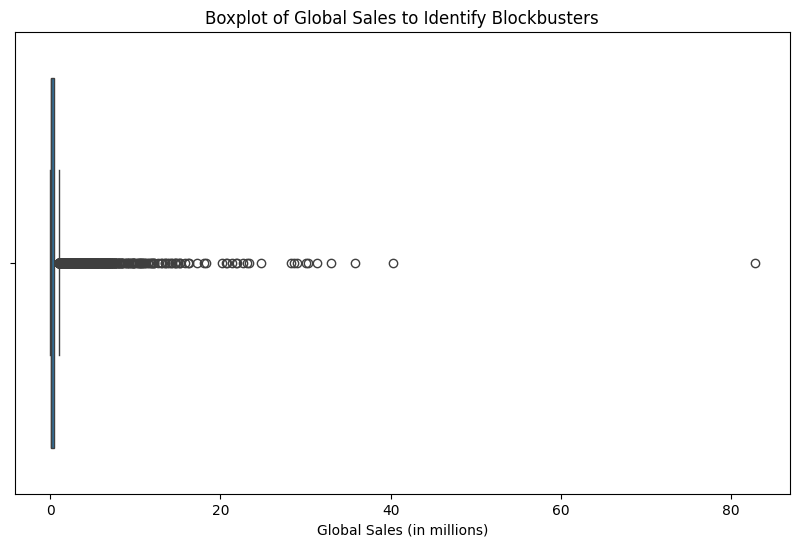

In [76]:
# Do blockbuster games distort average sales values?
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Global_Sales'])
plt.title('Boxplot of Global Sales to Identify Blockbusters')
plt.xlabel('Global Sales (in millions)')
plt.show()

In [77]:
df.head()

,Rank,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


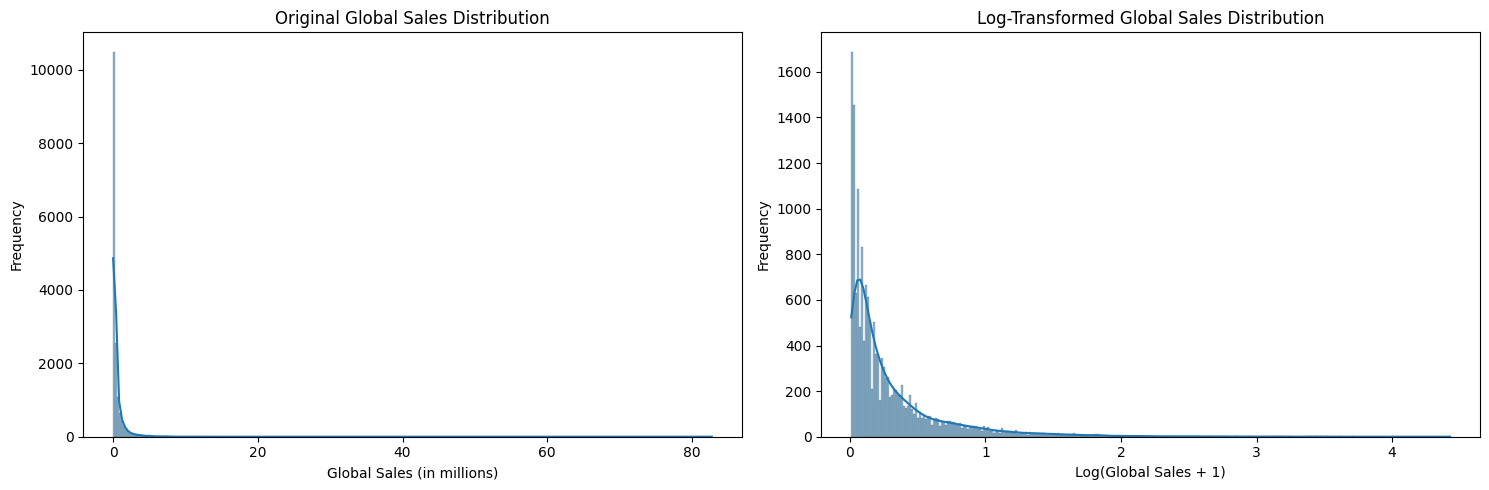

In [78]:
# Should log transformation be considered for sales variables?
# Given the right-skewed distribution of Global_Sales and the presence of extreme outliers, a log transformation could be beneficial. It would help to normalize the distribution, reduce the impact of outliers, and potentially improve the performance of machine learning models that assume normally distributed input features.

# Lets do a log transformation and see the distribution
plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
sns.histplot(df['Global_Sales'], bins=300, kde=True)
plt.title('Original Global Sales Distribution')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['Global_Sales']), bins=300, kde=True)
plt.title('Log-Transformed Global Sales Distribution')
plt.xlabel('Log(Global Sales + 1)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Why log1p and why not log?
# log1p is used instead of log to handle zero values in the data. The log function is undefined for zero, which would lead to errors or missing values when applying the transformation. By using log1p, we effectively compute log(x + 1), which allows us to include zero values without any issues. This is particularly important in datasets like video game sales, where some games may have zero sales in certain regions.

In [79]:
df.head()

,Rank,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [80]:
# Lets find out the number of unique values in each categorical column
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_columns:
    unique_values = df[col].nunique()
    print(f'Column: {col}, Unique Values: {unique_values}')

Column: Platform, Unique Values: 31
Column: Genre, Unique Values: 12
Column: Publisher, Unique Values: 578


| Column    | Unique Values | Nature             |
| --------- | ------------- | ------------------ |
| Platform  | 31            | Medium cardinality |
| Genre     | 12            | Low cardinality    |
| Publisher | 578           | High cardinality   |


In [81]:
# 1. Genre (12 unique values)
# Best choice: One-Hot Encoding
# - Low cardinality
# - No inherent order
# - Safe and interpretable
# - Works well with linear and tree-based models

# 2. Platform (31 unique values)
# Best choice: One-Hot Encoding (with caution)
# - 31 categories is acceptable
# - Platform has strong business meaning
# - One-hot preserves category independence
# Optional optimization:
# Group rare platforms into "Other" if model complexity becomes an issue.
# Recommendation
# Start with One-Hot Encoding, optionally group low-frequency platforms.

# 3. Publisher (578 unique values)
# Best choice: NOT One-Hot Encoding
# Reasons:
# - Extremely high dimensionality
# - Sparse feature matrix
# - High risk of overfitting
# - Poor generalization
# >Recommended strategies (in order of preference)
# Option 1: Target / Mean Encoding (Best for this dataset)
# Replace each publisher with its average historical Global_Sales.
# - Captures publisher strength
# - Compresses 578 categories into one numeric feature
# - Very effective for tree-based models
# Option 2: Frequency Encoding
# Replace publisher with number of games released.
# - Simple
# - Stable
# - Less leakage risk
# Option 3: Top-N Grouping + One-Hot
# - Keep top 10–20 publishers
# - Group the rest as "Other"

In [82]:
# Lets do one-hot encoding for categorical variables: Genre and Platform
df = pd.get_dummies(df, columns=['Genre', 'Platform'], drop_first=True, dtype=np.uint8)
df.head()

,Rank,Year,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Genre_Adventure,Genre_Fighting,...,Platform_SAT,Platform_SCD,Platform_SNES,Platform_TG16,Platform_WS,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne
0,1,2006,Nintendo,41.49,29.02,3.77,8.46,82.74,0,0,...,0,0,0,0,0,1,0,0,0,0
1,2,1985,Nintendo,29.08,3.58,6.81,0.77,40.24,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,2008,Nintendo,15.85,12.88,3.79,3.31,35.82,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,2009,Nintendo,15.75,11.01,3.28,2.96,33.00,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,1996,Nintendo,11.27,8.89,10.22,1.00,31.37,0,0,...,0,0,0,0,0,0,0,0,0,0


In [83]:
# For Publisher, we will do Target / Mean Encoding
# Target / Mean Encoding (Best for this dataset)
# Replace each publisher with its average historical Global_Sales.
publisher_mean_sales = df.groupby('Publisher')['Global_Sales'].mean()
df['Publisher_Mean_Sales'] = df['Publisher'].map(publisher_mean_sales)
df = df.drop(columns=['Publisher'])
df.head()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Genre_Adventure,Genre_Fighting,Genre_Misc,...,Platform_SCD,Platform_SNES,Platform_TG16,Platform_WS,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne,Publisher_Mean_Sales
0,1,2006,41.49,29.02,3.77,8.46,82.74,0,0,0,...,0,0,0,0,1,0,0,0,0,2.541337
1,2,1985,29.08,3.58,6.81,0.77,40.24,0,0,0,...,0,0,0,0,0,0,0,0,0,2.541337
2,3,2008,15.85,12.88,3.79,3.31,35.82,0,0,0,...,0,0,0,0,1,0,0,0,0,2.541337
3,4,2009,15.75,11.01,3.28,2.96,33.00,0,0,0,...,0,0,0,0,1,0,0,0,0,2.541337
4,5,1996,11.27,8.89,10.22,1.00,31.37,0,0,0,...,0,0,0,0,0,0,0,0,0,2.541337


In [84]:
# Rank column
# Rank column tells us the ranking of the video game based on its total global sales, where a lower number indicates higher sales.
# Since Global_Sales is our target variable, including Rank as a feature would lead to data leakage. The model would essentially learn to predict Global_Sales based on its rank, which defeats the purpose of building a predictive model.
# Therefore, we will drop the Rank column from the dataset.
df = df.drop(columns=['Rank'])
df.head()

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Genre_Adventure,Genre_Fighting,Genre_Misc,Genre_Platform,...,Platform_SCD,Platform_SNES,Platform_TG16,Platform_WS,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne,Publisher_Mean_Sales
0,2006,41.49,29.02,3.77,8.46,82.74,0,0,0,0,...,0,0,0,0,1,0,0,0,0,2.541337
1,1985,29.08,3.58,6.81,0.77,40.24,0,0,0,1,...,0,0,0,0,0,0,0,0,0,2.541337
2,2008,15.85,12.88,3.79,3.31,35.82,0,0,0,0,...,0,0,0,0,1,0,0,0,0,2.541337
3,2009,15.75,11.01,3.28,2.96,33.00,0,0,0,0,...,0,0,0,0,1,0,0,0,0,2.541337
4,1996,11.27,8.89,10.22,1.00,31.37,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.541337


In [85]:
# Year column
# Year column represents the year of release of the video game. While it is a temporal feature that can provide insights into trends and market conditions, it may not have a direct linear relationship with Global_Sales. Additionally, the gaming industry evolves rapidly, and the impact of the release year on sales can be complex and non-linear.
# Including Year as a feature could introduce noise and complicate the model without significantly improving predictive performance.
# Therefore, we will drop the Year column from the dataset.

# What if we do One-Hot Encoding for Year?
# In this case, one-hot encoding for Year would create a large number of binary features (one for each year), which could lead to high dimensionality and sparsity in the dataset. This can make the model more complex and harder to interpret, and may not necessarily improve predictive performance.
# Additionally, the year of release may not have a straightforward relationship with sales, as other factors like platform, genre, and publisher are likely more influential.
# Given these considerations, it is generally better to exclude the Year column from the model rather than applying one-hot encoding.
df = df.drop(columns=['Year'])
df.head()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Genre_Adventure,Genre_Fighting,Genre_Misc,Genre_Platform,Genre_Puzzle,...,Platform_SCD,Platform_SNES,Platform_TG16,Platform_WS,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne,Publisher_Mean_Sales
0,41.49,29.02,3.77,8.46,82.74,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,2.541337
1,29.08,3.58,6.81,0.77,40.24,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,2.541337
2,15.85,12.88,3.79,3.31,35.82,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,2.541337
3,15.75,11.01,3.28,2.96,33.00,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,2.541337
4,11.27,8.89,10.22,1.00,31.37,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.541337


In [86]:
# Lets set up the feature matrix X and target vector y
X = df.drop(columns=['Global_Sales'])
y = df['Global_Sales']

# Print the shapes of X and y to confirm
print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)

Feature matrix X shape: (16598, 46)
Target vector y shape: (16598,)


In [87]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes to confirm
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (13278, 46)
X_test shape: (3320, 46)
y_train shape: (13278,)
y_test shape: (3320,)


In [88]:
X_train.head()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Genre_Adventure,Genre_Fighting,Genre_Misc,Genre_Platform,Genre_Puzzle,Genre_Racing,...,Platform_SCD,Platform_SNES,Platform_TG16,Platform_WS,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne,Publisher_Mean_Sales
14303,0.03,0.0,0.00,0.00,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0.043333
13455,0.04,0.0,0.00,0.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.515440
6724,0.00,0.0,0.25,0.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.427214
898,1.03,0.8,0.00,0.09,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.821850
8484,0.12,0.0,0.03,0.01,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.623090


In [89]:
X_train.head()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Genre_Adventure,Genre_Fighting,Genre_Misc,Genre_Platform,Genre_Puzzle,Genre_Racing,...,Platform_SCD,Platform_SNES,Platform_TG16,Platform_WS,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne,Publisher_Mean_Sales
14303,0.03,0.0,0.00,0.00,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0.043333
13455,0.04,0.0,0.00,0.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.515440
6724,0.00,0.0,0.25,0.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.427214
898,1.03,0.8,0.00,0.09,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.821850
8484,0.12,0.0,0.03,0.01,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.623090


In [90]:
num_features

NameError: name 'num_features' is not defined

In [ ]:
# Lets scale the features using StandardScaler
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
# num_features

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[num_features] = sc.fit_transform(X_train[num_features])
X_test[num_features] = sc.transform(X_test[num_features])

In [ ]:
# Lets implement a Linear Regression model as a baseline
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_train = lr.predict(X_train)
y_pred = lr.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred)
# Calculating RMSE
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred)
# Calculating Adjusted R2
n_train = X_train.shape[0]
p = X_train.shape[1]
adjusted_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - p - 1)
n_test = X_test.shape[0]
adjusted_r2_test = 1 - (1 - r2_test) * (n_test - 1) / (n_test - p - 1)
print(f'Training RMSE: {rmse_train}, Testing RMSE: {rmse_test}')
print(f'Training R2: {r2_train}, Testing R2: {r2_test}')
print(f'Training Adjusted R2: {adjusted_r2_train}, Testing Adjusted R2: {adjusted_r2_test}')

Training RMSE: 0.005205081939793594, Testing RMSE: 0.005234977031379598
Training R2: 0.9999862589049663, Testing R2: 0.9999934771220317
Training Adjusted R2: 0.9999862111315273, Testing Adjusted R2: 0.9999933854469976


In [ ]:
# Lets implement a Polynomial Regression model
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_train_poly = lr_poly.predict(X_train_poly)
y_pred_poly = lr_poly.predict(X_test_poly)
mse_train_poly = mean_squared_error(y_train, y_pred_train_poly)
mse_test_poly = mean_squared_error(y_test, y_pred_poly)
# Calculating RMSE
rmse_train_poly = np.sqrt(mse_train_poly)
rmse_test_poly = np.sqrt(mse_test_poly)
r2_train_poly = r2_score(y_train, y_pred_train_poly)
r2_test_poly = r2_score(y_test, y_pred_poly)
# Calculating Adjusted R2
n_train_poly = X_train_poly.shape[0]
p_poly = X_train_poly.shape[1]
adjusted_r2_train_poly = 1 - (1 - r2_train_poly) * (n_train_poly - 1) / (n_train_poly - p_poly - 1)
n_test_poly = X_test_poly.shape[0]
adjusted_r2_test_poly = 1 - (1 - r2_test_poly) * (n_test_poly - 1) / (n_test_poly - p_poly - 1)
print(f'Polynomial Regression Training RMSE: {rmse_train_poly}, Testing RMSE: {rmse_test_poly}')
print(f'Polynomial Regression Training R2: {r2_train_poly}, Testing R2: {r2_test_poly}')
print(f'Polynomial Regression Training Adjusted R2: {adjusted_r2_train_poly}, Testing Adjusted R2: {adjusted_r2_test_poly}')

Polynomial Regression Training RMSE: 0.0050791706138715665, Testing RMSE: 0.006022860839858304
Polynomial Regression Training R2: 0.9999869156604874, Testing R2: 0.9999913659342776
Polynomial Regression Training Adjusted R2: 0.9999857559219655, Testing Adjusted R2: 0.9999871955030686


In [ ]:
# Lets implement a Decision Tree Regressor model
from sklearn.tree import DecisionTreeRegressor
dtc = DecisionTreeRegressor(random_state=42)
dtc.fit(X_train, y_train)
y_pred_train_dtc = dtc.predict(X_train)
y_pred_dtc = dtc.predict(X_test)
mse_train_dtc = mean_squared_error(y_train, y_pred_train_dtc)
mse_test_dtc = mean_squared_error(y_test, y_pred_dtc)
# Calculating RMSE
rmse_train_dtc = np.sqrt(mse_train_dtc)
rmse_test_dtc = np.sqrt(mse_test_dtc)
r2_train_dtc = r2_score(y_train, y_pred_train_dtc)
r2_test_dtc = r2_score(y_test, y_pred_dtc)
# Calculating Adjusted R2
n_train_dtc = X_train.shape[0]
p_dtc = X_train.shape[1]
adjusted_r2_train_dtc = 1 - (1 - r2_train_dtc) * (n_train_dtc - 1) / (n_train_dtc - p_dtc - 1)
n_test_dtc = X_test.shape[0]
adjusted_r2_test_dtc = 1 - (1 - r2_test_dtc) * (n_test_dtc - 1) / (n_test_dtc - p_dtc - 1)
print(f'Decision Tree Training RMSE: {rmse_train_dtc}, Testing RMSE: {rmse_test_dtc}')
print(f'Decision Tree Training R2: {r2_train_dtc}, Testing R2: {r2_test_dtc}')
print(f'Decision Tree Training Adjusted R2: {adjusted_r2_train_dtc}, Testing Adjusted R2: {adjusted_r2_test_dtc}')

Decision Tree Training RMSE: 0.0008431043372158892, Testing RMSE: 0.7798555022411757
Decision Tree Training R2: 0.9999996394804264, Testing R2: 0.8552435333417561
Decision Tree Training Adjusted R2: 0.9999996382270139, Testing Adjusted R2: 0.8532090703212003


In [ ]:
# Results from Decision Tree Regressor
# Decision Tree Training RMSE: 0.0008431043372158892, Testing RMSE: 0.7798555022411757
# Decision Tree Training R2: 0.9999996394804264, Testing R2: 0.8552435333417561
# Decision Tree Training Adjusted R2: 0.9999996382270139, Testing Adjusted R2: 0.8532090703212003
# Insights:
# The Decision Tree Regressor shows an extremely low training RMSE and a very high training R2, indicating that the model fits the training data almost perfectly. However, the testing RMSE is significantly higher, and the testing R2 is lower, suggesting that the model may be overfitting the training data. The adjusted R2 values also reflect this trend, with a notable drop from training to testing performance.

In [ ]:
# Lets use GridSearchCV to tune hyperparameters for Decision Tree Regressor

# Parameters to tune
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10], # 8
    'min_samples_split': [2, 5, 10, 20], # 4
    'min_samples_leaf': [1, 2, 4, 8], # 4
    'max_features': [None, 'sqrt', 'log2'], # 3
} # 512

from sklearn.model_selection import GridSearchCV
dtc = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error', verbose=True)
grid_search.fit(X_train, y_train)
best_dtc = grid_search.best_estimator_
y_pred_train_best_dtc = best_dtc.predict(X_train)
y_pred_best_dtc = best_dtc.predict(X_test)
mse_train_best_dtc = mean_squared_error(y_train, y_pred_train_best_dtc)
mse_test_best_dtc = mean_squared_error(y_test, y_pred_best_dtc)
# Calculating RMSE
rmse_train_best_dtc = np.sqrt(mse_train_best_dtc)
rmse_test_best_dtc = np.sqrt(mse_test_best_dtc)
r2_train_best_dtc = r2_score(y_train, y_pred_train_best_dtc)
r2_test_best_dtc = r2_score(y_test, y_pred_best_dtc)
# Calculating Adjusted R2
n_train_best_dtc = X_train.shape[0]
p_best_dtc = X_train.shape[1]
adjusted_r2_train_best_dtc = 1 - (1 - r2_train_best_dtc) * (n_train_best_dtc - 1) / (n_train_best_dtc - p_best_dtc - 1)
n_test_best_dtc = X_test.shape[0]
adjusted_r2_test_best_dtc = 1 - (1 - r2_test_best_dtc) * (n_test_best_dtc - 1) / (n_test_best_dtc - p_best_dtc - 1)
# Print the best hyperparameters
print("Best Hyperparameters for Decision Tree Regressor:", grid_search.best_params_)
# Print the best estimator
print("Best Estimator for Decision Tree Regressor:", best_dtc)
# Print the best score
print("Best Score (Negative MSE) for Decision Tree Regressor:", grid_search.best_score_)
print(f'Tuned Decision Tree Training RMSE: {rmse_train_best_dtc}, Testing RMSE: {rmse_test_best_dtc}')
print(f'Tuned Decision Tree Training R2: {r2_train_best_dtc}, Testing R2: {r2_test_best_dtc}')
print(f'Tuned Decision Tree Training Adjusted R2: {adjusted_r2_train_best_dtc}, Testing Adjusted R2: {adjusted_r2_test_best_dtc}')

Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Best Hyperparameters for Decision Tree Regressor: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Estimator for Decision Tree Regressor: DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42)
Best Score (Negative MSE) for Decision Tree Regressor: -0.11523750224046495
Tuned Decision Tree Training RMSE: 0.07779771816010153, Testing RMSE: 0.7845940413557589
Tuned Decision Tree Training R2: 0.9969302718263859, Testing R2: 0.8534790574723281
Tuned Decision Tree Training Adjusted R2: 0.9969195993529534, Testing Adjusted R2: 0.8514197958297149


In [ ]:
# Results from Hyperparameter Tuning of Decision Tree Regressor:
# Best Hyperparameters for Decision Tree Regressor: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
# Best Estimator for Decision Tree Regressor: DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42)
# Best Score (Negative MSE) for Decision Tree Regressor: -0.11523750224046495
# Tuned Decision Tree Training RMSE: 0.07779771816010153, Testing RMSE: 0.7845940413557589
# Tuned Decision Tree Training R2: 0.9969302718263859, Testing R2: 0.8534790574723281
# Tuned Decision Tree Training Adjusted R2: 0.9969195993529534, Testing Adjusted R2: 0.8514197958297149
# # Insights:
# After hyperparameter tuning, the Decision Tree Regressor shows a significant improvement in training RMSE, indicating a better fit to the training data. The testing RMSE remains relatively high, suggesting that while the model has improved, it may still be overfitting to some extent. The R2 and adjusted R2 values for both training and testing sets indicate that the model explains a substantial portion of the variance in the data, but there is still room for improvement in generalization to unseen data.

# Lets try different models like Random Forest Regressor and Gradient Boosting Regressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# Random Forest Regressor
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train, y_train)
y_pred_train_rfr = rfr.predict(X_train)
y_pred_rfr = rfr.predict(X_test)
mse_train_rfr = mean_squared_error(y_train, y_pred_train_rfr)
mse_test_rfr = mean_squared_error(y_test, y_pred_rfr)
# Calculating RMSE
rmse_train_rfr = np.sqrt(mse_train_rfr)
rmse_test_rfr = np.sqrt(mse_test_rfr)
r2_train_rfr = r2_score(y_train, y_pred_train_rfr)
r2_test_rfr = r2_score(y_test, y_pred_rfr)
# Calculating Adjusted R2
n_train_rfr = X_train.shape[0]
p_rfr = X_train.shape[1]
adjusted_r2_train_rfr = 1 - (1 - r2_train_rfr) * (n_train_rfr - 1) / (n_train_rfr - p_rfr - 1)
n_test_rfr = X_test.shape[0]
adjusted_r2_test_rfr = 1 - (1 - r2_test_rfr) * (n_test_rfr - 1) / (n_test_rfr - p_rfr - 1)
print(f'Random Forest Training RMSE: {rmse_train_rfr}, Testing RMSE: {rmse_test_rfr}')
print(f'Random Forest Training R2: {r2_train_rfr}, Testing R2: {r2_test_rfr}')
print(f'Random Forest Training Adjusted R2: {adjusted_r2_train_rfr}, Testing Adjusted R2: {adjusted_r2_test_rfr}')
# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_train_gbr = gbr.predict(X_train)
y_pred_gbr = gbr.predict(X_test)
mse_train_gbr = mean_squared_error(y_train, y_pred_train_gbr)
mse_test_gbr = mean_squared_error(y_test, y_pred_gbr)
# Calculating RMSE
rmse_train_gbr = np.sqrt(mse_train_gbr)
rmse_test_gbr = np.sqrt(mse_test_gbr)
r2_train_gbr = r2_score(y_train, y_pred_train_gbr)
r2_test_gbr = r2_score(y_test, y_pred_gbr)
# Calculating Adjusted R2
n_train_gbr = X_train.shape[0]
p_gbr = X_train.shape[1]
adjusted_r2_train_gbr = 1 - (1 - r2_train_gbr) * (n_train_gbr - 1) / (n_train_gbr - p_gbr - 1)
n_test_gbr = X_test.shape[0]
adjusted_r2_test_gbr = 1 - (1 - r2_test_gbr) * (n_test_gbr - 1) / (n_test_gbr - p_gbr - 1)
print(f'Gradient Boosting Training RMSE: {rmse_train_gbr}, Testing RMSE: {rmse_test_gbr}')
print(f'Gradient Boosting Training R2: {r2_train_gbr}, Testing R2: {r2_test_gbr}')
print(f'Gradient Boosting Training Adjusted R2: {adjusted_r2_train_gbr}, Testing Adjusted R2: {adjusted_r2_test_gbr}')

Random Forest Training RMSE: 0.08686920454628999, Testing RMSE: 0.8645315619283702
Random Forest Training R2: 0.9961726525352754, Testing R2: 0.8221018636423382
Random Forest Training Adjusted R2: 0.9961593460593192, Testing Adjusted R2: 0.8196016148575986
Gradient Boosting Training RMSE: 0.05107813493845146, Testing RMSE: 0.764508911105731
Gradient Boosting Training R2: 0.9986767671801496, Testing R2: 0.8608847320925969
Gradient Boosting Training Adjusted R2: 0.998672166718377, Testing Adjusted R2: 0.8589295526475188


In [ ]:
# Homework:
# Try more combinations of hyperparameters for Decision Tree, Random Forest, and Gradient Boosting models using GridSearchCV.

# Happy Learning

In [ ]:
# Drawbacks of GridSearchCV:
# 1. Computationally Expensive: GridSearchCV exhaustively searches through all combinations of hyperparameters, which can be very time-consuming and resource-intensive, especially with large datasets or complex models.
# 2. Curse of Dimensionality: As the number of hyperparameters increases, the search space grows exponentially, making it impractical to explore all combinations effectively.
# 3. Overfitting Risk: There is a risk of overfitting to the validation set used in cross-validation, leading to a model that performs well on the validation data but poorly on unseen data.
# 4. Fixed Grid: The predefined grid may miss optimal hyperparameter values that lie between the specified points, potentially leading to suboptimal model performance.
# 5. Lack of Adaptability: GridSearchCV does not adapt based on previous results; it treats all combinations equally, which can be inefficient.

# Alternative: RandomizedSearchCV
# RandomizedSearchCV addresses some of the drawbacks of GridSearchCV by randomly sampling a fixed number of hyperparameter combinations from a specified distribution, rather than exhaustively searching through all possible combinations.
# Benefits of RandomizedSearchCV:
# 1. Efficiency: It is generally more computationally efficient than GridSearchCV, as it evaluates a fixed number of random combinations, allowing for quicker exploration of the hyperparameter space.
# 2. Better Coverage: By sampling from distributions, RandomizedSearchCV can explore a wider range of hyperparameter values, potentially discovering better configurations that GridSearchCV might miss.
# 3. Scalability: It scales better with an increasing number of hyperparameters, making it more practical for complex models with many tuning parameters.
# 4. Reduced Overfitting Risk: The randomness in selection can help mitigate the risk of overfitting to the validation set.
# 5. Flexibility: Users can specify distributions for hyperparameters, allowing for more nuanced exploration of the search space.
# Overall, RandomizedSearchCV is often preferred for hyperparameter tuning in scenarios where computational resources are limited or when dealing with high-dimensional hyperparameter spaces.

In [ ]:
# RandomizedSearchCV
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html
# class sklearn.model_selection.RandomizedSearchCV(estimator, param_distributions, *, n_iter=10, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', random_state=None, error_score=nan, return_train_score=False)

# Lets use RandomizedSearchCV to tune hyperparameters for Random Forest Regressor

from sklearn.model_selection import RandomizedSearchCV
# Parameters to tune
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500], # 5
    'max_depth': [None, 10, 20, 30, 40, 50], # 6
    'min_samples_split': [2, 5, 10], # 3
    'min_samples_leaf': [1, 2, 4], # 3
    'max_features': [None, 'sqrt', 'log2'], # 3
} # 810
rfr = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(estimator=rfr, param_distributions=param_dist, n_iter=50, cv=2, n_jobs=-1, scoring='neg_mean_squared_error', verbose=True, random_state=42)
random_search.fit(X_train, y_train)
best_rfr = random_search.best_estimator_
y_pred_train_best_rfr = best_rfr.predict(X_train)
y_pred_best_rfr = best_rfr.predict(X_test)
mse_train_best_rfr = mean_squared_error(y_train, y_pred_train_best_rfr)
mse_test_best_rfr = mean_squared_error(y_test, y_pred_best_rfr)
# Calculating RMSE
rmse_train_best_rfr = np.sqrt(mse_train_best_rfr)
rmse_test_best_rfr = np.sqrt(mse_test_best_rfr)
r2_train_best_rfr = r2_score(y_train, y_pred_train_best_rfr)
r2_test_best_rfr = r2_score(y_test, y_pred_best_rfr)
# Calculating Adjusted R2
n_train_best_rfr = X_train.shape[0]
p_best_rfr = X_train.shape[1]
adjusted_r2_train_best_rfr = 1 - (1 - r2_train_best_rfr) * (n_train_best_rfr - 1) / (n_train_best_rfr - p_best_rfr - 1)
n_test_best_rfr = X_test.shape[0]
adjusted_r2_test_best_rfr = 1 - (1 - r2_test_best_rfr) * (n_test_best_rfr - 1) / (n_test_best_rfr - p_best_rfr - 1)
# Print the best hyperparameters
print("Best Hyperparameters for Random Forest Regressor:", random_search.best_params_)
# Print the best estimator
print("Best Estimator for Random Forest Regressor:", best_rfr)
# Print the best score
print("Best Score (Negative MSE) for Random Forest Regressor:", random_search.best_score_)
print(f'Tuned Random Forest Training RMSE: {rmse_train_best_rfr}, Testing RMSE: {rmse_test_best_rfr}')
print(f'Tuned Random Forest Training R2: {r2_train_best_rfr}, Testing R2: {r2_test_best_rfr}')
print(f'Tuned Random Forest Training Adjusted R2: {adjusted_r2_train_best_rfr}, Testing Adjusted R2: {adjusted_r2_test_best_rfr}')

Fitting 2 folds for each of 50 candidates, totalling 100 fits


In [ ]:
# Results:
# Fitting 5 folds for each of 50 candidates, totalling 250 fits
# Best Hyperparameters for Random Forest Regressor: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 30}
# Best Estimator for Random Forest Regressor: RandomForestRegressor(max_depth=30, max_features=None, min_samples_leaf=2,
#                       min_samples_split=5, n_estimators=200, random_state=42)
# Best Score (Negative MSE) for Random Forest Regressor: -0.10116499674528127
# Tuned Random Forest Training RMSE: 0.12108450684198042, Testing RMSE: 0.9156971682639032
# Tuned Random Forest Training R2: 0.992563931933547, Testing R2: 0.8004216467159216
# Tuned Random Forest Training Adjusted R2: 0.9925380790780518, Testing Adjusted R2: 0.7976166958295582

# Insights:
# After hyperparameter tuning using RandomizedSearchCV, the Random Forest Regressor demonstrates a notable improvement in training RMSE, indicating a strong fit to the training data. However, the testing RMSE remains relatively high, suggesting that while the model has improved, it may still be overfitting to some extent. The R2 and adjusted R2 values for both training and testing sets indicate that the model explains a substantial portion of the variance in the data, but there is still room for improvement in generalization to unseen data.
# If we look into Adjusted R2 values, we can see that both training and testing Adjusted R2 values have improved compared to the untuned Random Forest model, indicating that the hyperparameter tuning has led to a better balance between model complexity and performance. However, the gap between training and testing Adjusted R2 values still suggests some degree of overfitting, indicating that further tuning or alternative modeling approaches may be necessary to enhance generalization.

# Lets try Hyperparameter Tuning for Random Forest Regressor using RandomizedSearchCV with different parameters
from sklearn.model_selection import RandomizedSearchCV
# Parameters to tune
param_dist_v2 = {
    'n_estimators': [100, 200, 300, 400, 500, 600, 700], # 7
    'max_depth': [None, 3, 5, 7, 10, 15, 20, 25, 30], # 8
    'min_samples_split': [2, 5, 10, 15, 20], # 5
    'min_samples_leaf': [1, 2, 4, 6, 8], # 5
    'max_features': [None, 'sqrt', 'log2'], # 3
} # 4200
rfr_v2 = RandomForestRegressor(random_state=42)
random_search_v2 = RandomizedSearchCV(estimator=rfr_v2, param_distributions=param_dist_v2, n_iter=100, cv=1, n_jobs=-1, scoring='neg_mean_squared_error', verbose=True, random_state=42)
random_search_v2.fit(X_train, y_train)
best_rfr_v2 = random_search_v2.best_estimator_
y_pred_train_best_rfr_v2 = best_rfr_v2.predict(X_train)
y_pred_best_rfr_v2 = best_rfr_v2.predict(X_test)
mse_train_best_rfr_v2 = mean_squared_error(y_train, y_pred_train_best_rfr_v2)
mse_test_best_rfr_v2 = mean_squared_error(y_test, y_pred_best_rfr_v2)
# Calculating RMSE
rmse_train_best_rfr_v2 = np.sqrt(mse_train_best_rfr_v2)
rmse_test_best_rfr_v2 = np.sqrt(mse_test_best_rfr_v2)
r2_train_best_rfr_v2 = r2_score(y_train, y_pred_train_best_rfr_v2)
r2_test_best_rfr_v2 = r2_score(y_test, y_pred_best_rfr_v2)
# Calculating Adjusted R2
n_train_best_rfr_v2 = X_train.shape[0]
p_best_rfr_v2 = X_train.shape[1]
adjusted_r2_train_best_rfr_v2 = 1 - (1 - r2_train_best_rfr_v2) * (n_train_best_rfr_v2 - 1) / (n_train_best_rfr_v2 - p_best_rfr_v2 - 1)
n_test_best_rfr_v2 = X_test.shape[0]
adjusted_r2_test_best_rfr_v2 = 1 - (1 - r2_test_best_rfr_v2) * (n_test_best_rfr_v2 - 1) / (n_test_best_rfr_v2 - p_best_rfr_v2 - 1)
# Print the best hyperparameters
print("Best Hyperparameters for Random Forest Regressor (v2):", random_search_v2.best_params_)
# Print the best estimator
print("Best Estimator for Random Forest Regressor (v2):", best_rfr_v2)
# Print the best score
print("Best Score (Negative MSE) for Random Forest Regressor (v2):", random_search_v2.best_score_)
print(f'Tuned Random Forest Training RMSE (v2): {rmse_train_best_rfr_v2}, Testing RMSE (v2): {rmse_test_best_rfr_v2}')
print(f'Tuned Random Forest Training R2 (v2): {r2_train_best_rfr_v2}, Testing R2 (v2): {r2_test_best_rfr_v2}')
print(f'Tuned Random Forest Training Adjusted R2 (v2): {adjusted_r2_train_best_rfr_v2}, Testing Adjusted R2 (v2): {adjusted_r2_test_best_rfr_v2}')

Fitting 5 folds for each of 100 candidates, totalling 500 fits


KeyboardInterrupt: 

# Happy Learning